# FIP 00 — Fiber photometry exploration

A learning notebook for **accessing and plotting fiber photometry (FIP) data**, as a first
step toward correlating the photometry signals with movement.

**Where this runs:** Code Ocean. The data lives in a Code Ocean data asset, not locally.
Attach the asset so it mounts under `/root/capsule/data/`.

- Data asset ID: `6babbf3d-6970-4456-aab5-d730ed57c269`

**Data format:** this asset is a **saved parquet hierarchy** (the output of
`save_nwb_list`), *not* raw `.nwb` files. We load it with Rachel's library
(`rachel_analysis_utils.nwb_utils.load_nwb_list`), which expects:

```
plot_loc/
    df_sess*.csv            (optional)
    rpe_slope.csv           (optional)
    <subject_id>/
        <session_id>/
            df_events.parquet
            df_fip.parquet      # columns: ses_idx, event, data, timestamps, ...
            df_trials.parquet
```

**FIP signal layout:** each row of `df_fip` belongs to one `event` series named
`{channel}_{fiber}` (+ processed variants like `*_dff`):
- **channels**: `G` (green / GCaMP), `R` (red), `Iso` (isosbestic control)
- **fibers**: `0`–`4` (the implanted fiber / brain region)

**Curation toggle:** `USE_CURATION` (section 3) switches between two versions — raw traces
by fiber number, or `apply_curation_nwb_list` with a curation JSON that maps fibers to brain
regions and drops bad channels/sessions.

In [1]:
import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rachel's lab utilities (installed / mounted in the Code Ocean capsule).
from rachel_analysis_utils import nwb_utils as r_utils

# AIND event-alignment primitive (peri-event windowing). df_fip['timestamps'] and the
# df_trials '*_in_session' columns share one clock: t=0 is the first go cue of the session.
from aind_dynamic_foraging_data_utils import alignment

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
# load_nwb_list reads the parquet hierarchy with pd.read_parquet(..., engine="fastparquet"),
# which is hardcoded in rachel_analysis_utils. The capsule image doesn't ship fastparquet,
# so install it on first run. (No-op once it's importable.) For a permanent fix, add
# `fastparquet` to the Code Ocean environment instead.
try:
    import fastparquet  # noqa: F401
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "fastparquet"])
    import fastparquet  # noqa: F401
print("fastparquet", fastparquet.__version__)

fastparquet 2024.11.0


## 1. Point at the saved parquet hierarchy

`load_nwb_list(plot_loc)` wants a root directory laid out as
`plot_loc/<subject>/<session>/df_fip.parquet`. The data for this project lives at
`/root/capsule/data/DA_NE_4channels/` (212 sessions), so we hardwire `plot_loc` rather than
globbing the whole asset every session. Flip `RELOCATE=True` to rediscover it by glob if the
asset layout ever changes.

In [3]:
# Hardwired to the attached asset's saved parquet hierarchy so we skip the
# recursive glob every session. This is the `plot_loc` root that load_nwb_list
# wants: plot_loc/<subject>/<session>/df_fip.parquet
plot_loc = "/root/capsule/data/DA_NE_4channels/"

assert os.path.isdir(plot_loc), (
    f"{plot_loc} not found. Attach asset 6babbf3d-6970-4456-aab5-d730ed57c269 "
    "(saved parquet hierarchy) to this capsule, or fix the path."
)
print("plot_loc =", plot_loc)

# Fallback: if the layout ever changes, set RELOCATE=True to rediscover by glob.
RELOCATE = False
if RELOCATE:
    fip_files = glob.glob(os.path.join("/root/capsule/data", "**", "df_fip.parquet"), recursive=True)
    plot_locs = sorted({os.path.dirname(os.path.dirname(os.path.dirname(f))) for f in fip_files})
    print(f"{len(fip_files)} session(s) found across {len(plot_locs)} root(s):", plot_locs)

plot_loc = /root/capsule/data/DA_NE_4channels/


## 2. Load sessions with `load_nwb_list`

Returns a list of `dummy_nwb` objects (each with `.df_fip`, `.df_trials`, `.df_events`,
`.session_id`) plus optional session/slope tables. `load_fip=True` is required for the
photometry dataframes.

In [4]:
nwb_list_raw, df_sess, df_slope = r_utils.load_nwb_list(plot_loc, load_fip=True)

print(f"Loaded {len(nwb_list_raw)} session(s):")
for nwb in nwb_list_raw:
    has_fip = getattr(nwb, "df_fip", None) is not None
    print(f"  {nwb.session_id:<32s} fip={has_fip}")

loading 7 df_sess file(s)
no rpe_slope.csv found at plot location, skipping
loading 808054_2025-09-02
loading 808054_2025-09-03
loading 808054_2025-09-04
loading 808054_2025-09-05
loading 808054_2025-09-08
loading 808054_2025-09-09
loading 808054_2025-09-10
loading 808054_2025-09-11
loading 808054_2025-09-12
loading 808054_2025-09-15
loading 808054_2025-09-16
loading 808054_2025-09-17
loading 808054_2025-09-18
loading 808054_2025-09-19
loading 808054_2025-09-22
loading 808054_2025-09-23
loading 808054_2025-09-24
loading 808054_2025-09-25
loading 808054_2025-09-26
loading 808054_2025-10-02
loading 808054_2025-10-07
loading 808054_2025-10-08
loading 808054_2025-10-10
loading 808054_2025-10-13
loading 808054_2025-10-14
loading 808054_2025-10-15
loading 808054_2025-10-16
loading 808054_2025-10-17
loading 808056_2025-09-12
loading 808056_2025-09-15
loading 808056_2025-09-16
loading 808056_2025-09-17
loading 808056_2025-09-18
loading 808056_2025-09-22
loading 808056_2025-09-23
loading 808056

## 3. Curation — the toggle

Two versions, switched by `USE_CURATION`:

- **`False`** — use the raw `nwb_list`. Traces are labelled by fiber number only. Simplest
  for learning the data layout.
- **`True`** — run `apply_curation_nwb_list` with a curation JSON. This annotates
  `df_fip.intended_measurement` (fiber → brain region), renames `df_trials` columns, drops
  bad channels, and removes flagged sessions.

⚠️ `CeA_datacuration_firstpass.json` is **project-specific** (BWNM central-amygdala). It is
only correct if your fibers match that mapping — otherwise make your own curation file with
the same schema and point `CURATION_FILE` at it.

In [37]:
USE_CURATION = True
CURATION_FILE = "DA_NE_4channel_datacuration_secondpass"

if USE_CURATION:
    # Locate the curation JSON inside the installed rachel package, with a /src fallback.
    json_path = None
    try:
        import rachel_analysis_utils
        pkg_dir = os.path.dirname(rachel_analysis_utils.__file__)
        cand = os.path.join(pkg_dir, "data_curation", CURATION_FILE + ".json")
        if os.path.exists(cand):
            json_path = cand
    except Exception:
        pass
    if json_path is None:
        hits = glob.glob("/src/**/data_curation/" + CURATION_FILE + ".json", recursive=True)
        assert hits, "Could not locate " + CURATION_FILE + ".json"
        json_path = hits[0]

    with open(json_path, "r") as fh:
        df_curation = json.load(fh)
    print("Using curation:", json_path)

    nwb_list, nwb_list_curated = r_utils.apply_curation_nwb_list(
        nwb_list_raw, df_curation, drop_borderline=True
    )
    print(f"Curated -> {len(nwb_list)} session(s) kept.")
else:
    nwb_list = nwb_list_raw
    print("No curation applied; using raw nwb_list.")

JSONDecodeError: Expecting ':' delimiter: line 4 column 3 (char 74)

## 4. Pick a session and inspect `df_fip`

Each `dummy_nwb` holds one session's tidy `df_fip`: columns `[ses_idx, event, data,
timestamps, ...]`, where `timestamps` are aligned so **t=0 is the first go cue**. Each unique
`event` is one (channel, fiber, variant) trace.

In [27]:
SESSION_IDX = 0
nwb = nwb_list[SESSION_IDX]
df_fip = nwb.df_fip

print("session_id:", nwb.session_id)
print("df_fip:", df_fip.shape, "| columns:", list(df_fip.columns))
df_fip.head(5)

session_id: 808054_2025-09-02
df_fip: (719016, 10) | columns: ['index', 'timestamps', 'data', 'event', 'raw_timestamps', 'ses_idx', 'data_z', 'data_norm', 'data_z_norm', 'week_interval']


,index,timestamps,data,event,raw_timestamps,ses_idx,data_z,data_norm,data_z_norm,week_interval
0,72450.0,-0.970016,-0.004545,R_2_dff-bright_mc-iso-IRLS,1.156210e+07,808054_2025-09-02,-0.787280,-0.003089,-0.476130,1.0
1,72451.0,-0.970016,0.006624,R_3_dff-bright_mc-iso-IRLS,1.156210e+07,808054_2025-09-02,0.522012,-0.001367,-0.145827,1.0
2,72453.0,-0.953498,-0.003663,G_1_dff-bright_mc-iso-IRLS,1.156210e+07,808054_2025-09-02,-0.342712,0.002996,0.255748,1.0
3,72452.0,-0.953498,0.012019,G_3_dff-bright_mc-iso-IRLS,1.156210e+07,808054_2025-09-02,-0.786389,-0.017663,-0.110154,1.0
4,72454.0,-0.953498,0.014334,G_2_dff-bright_mc-iso-IRLS,1.156210e+07,808054_2025-09-02,1.520917,0.012161,1.397213,1.0


In [17]:
events = sorted(df_fip["event"].unique())


def parse_event(name):
    """Split a FIP series name into (channel, fiber, variant).

    e.g. 'G_1_dff-poly' -> ('G', '1', 'dff-poly'); 'R_0' -> ('R', '0', 'raw').
    """
    parts = name.split("_")
    channel = parts[0]
    fiber = parts[1] if len(parts) > 1 else "?"
    variant = "_".join(parts[2:]) if len(parts) > 2 else "raw"
    return channel, fiber, variant


meta = pd.DataFrame(
    [(e,) + parse_event(e) for e in events],
    columns=["event", "channel", "fiber", "variant"],
)

# After curation, df_fip carries region labels in `intended_measurement`.
if "intended_measurement" in df_fip.columns:
    ev2region = (
        df_fip.dropna(subset=["intended_measurement"])
        .groupby("event")["intended_measurement"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None)
    )
    meta["region"] = meta["event"].map(ev2region)

print(f"{len(events)} FIP series")
meta

10 FIP series


,event,channel,fiber,variant
0,G_0:G_1_pearsonR,G,0:G,1_pearsonR
1,G_0:G_2_pearsonR,G,0:G,2_pearsonR
2,G_0_dff-bright_mc-iso-IRLS,G,0,dff-bright_mc-iso-IRLS
3,G_1:G_3_pearsonR,G,1:G,3_pearsonR
4,G_1_dff-bright_mc-iso-IRLS,G,1,dff-bright_mc-iso-IRLS
5,G_2:G_3_pearsonR,G,2:G,3_pearsonR
6,G_2_dff-bright_mc-iso-IRLS,G,2,dff-bright_mc-iso-IRLS
7,G_3_dff-bright_mc-iso-IRLS,G,3,dff-bright_mc-iso-IRLS
8,R_2_dff-bright_mc-iso-IRLS,R,2,dff-bright_mc-iso-IRLS
9,R_3_dff-bright_mc-iso-IRLS,R,3,dff-bright_mc-iso-IRLS


## 5. Plot full-session traces

Overlay G/R/Iso for one fiber. Iso is the isosbestic control — motion / bleaching artefacts
show up in both G and Iso, while real calcium transients appear in green only.

Plotting fiber 2, variant 'dff-bright_mc-iso-IRLS'


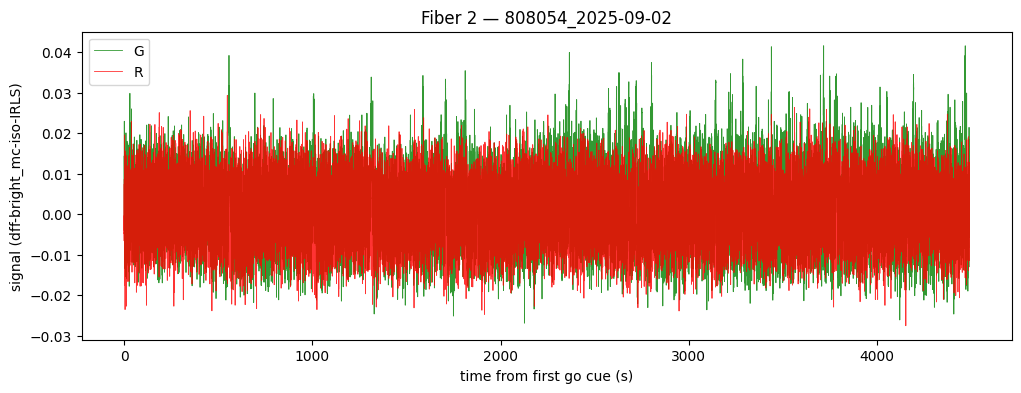

In [36]:
def get_trace(df_fip, event_name):
    """Return (t, y) sorted by time for one FIP series."""
    sub = df_fip[df_fip["event"] == event_name].sort_values("timestamps")
    return sub["timestamps"].to_numpy(), sub["data"].to_numpy()


# Pick the most common fiber and prefer a dff variant if present.
FIBER = meta["fiber"].mode().iloc[1]
variants_here = meta.loc[meta["fiber"] == FIBER, "variant"].unique()
VARIANT = next((v for v in variants_here if "dff" in v), variants_here[0])

region = None
if "region" in meta.columns:
    rvals = meta.loc[meta["fiber"] == FIBER, "region"].dropna().unique()
    region = rvals[0] if len(rvals) else None
label_suffix = (" (" + str(region) + ")") if region else ""
print(f"Plotting fiber {FIBER}{label_suffix}, variant '{VARIANT}'")

fig, ax = plt.subplots()
for ch, color in [("G", "green"), ("R", "red"), ("Iso", "gray")]:
    match = meta[(meta["channel"] == ch) & (meta["fiber"] == FIBER) & (meta["variant"] == VARIANT)]
    if match.empty:
        continue
    t, y = get_trace(df_fip, match["event"].iloc[0])
    ax.plot(t, y, color=color, lw=0.6, alpha=0.8, label=ch)

ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel(f"signal ({VARIANT})")
ax.set_title(f"Fiber {FIBER}{label_suffix} — {nwb.session_id}")
ax.legend()
plt.show()

## 6. Overlay behavioural events

Place the photometry in behavioural context using the same session's `df_trials`. We detect
the go-cue column (it differs across processing versions) and mark cues on a short window.

In [19]:
df_trials = getattr(nwb, "df_trials", None)
cue_col = None
if df_trials is not None:
    cue_col = next(
        (c for c in ["goCue_start_time_in_session", "goCue_start_time"] if c in df_trials.columns),
        None,
    )
    print("df_trials:", df_trials.shape, "| go-cue column:", cue_col)
else:
    print("No df_trials on this session.")

df_trials: (524, 113) | go-cue column: goCue_start_time_in_session


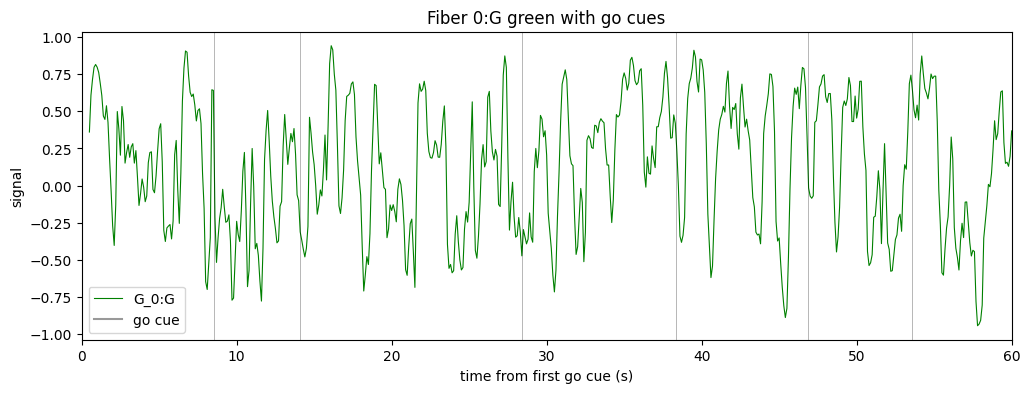

In [20]:
match = meta[(meta["channel"] == "G") & (meta["fiber"] == FIBER) & (meta["variant"] == VARIANT)]
assert not match.empty, "No green trace for chosen fiber/variant; adjust FIBER/VARIANT."
t, y = get_trace(df_fip, match["event"].iloc[0])

WINDOW = (0, 60)  # seconds from first go cue
m = (t >= WINDOW[0]) & (t <= WINDOW[1])

fig, ax = plt.subplots()
ax.plot(t[m], y[m], color="green", lw=0.8, label=f"G_{FIBER}{label_suffix}")
if cue_col is not None:
    cues = df_trials[cue_col]
    cues = cues[(cues >= WINDOW[0]) & (cues <= WINDOW[1])]
    for c in cues:
        ax.axvline(c, color="k", lw=0.5, alpha=0.4)
    ax.plot([], [], color="k", alpha=0.4, label="go cue")

ax.set_xlim(*WINDOW)
ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel("signal")
ax.set_title(f"Fiber {FIBER}{label_suffix} green with go cues")
ax.legend()
plt.show()

## 7. Peri-event average (a first real analysis)

Align the chosen signal to each go cue and average across trials. Instead of hand-rolling the
interpolation, we use the lab's standard primitive,
`aind_dynamic_foraging_data_utils.alignment.event_triggered_response` (ETR). It interpolates
each trial's snippet onto a common grid (`output_sampling_rate` Hz), and—unlike a naive
`np.interp`—**censors** samples that spill past the next event, so trials with short
inter-cue intervals don't leak into each other.

Two clock rules make this work:
- the **signal** is `df_fip['timestamps']` (first-go-cue-zeroed),
- the **event times** must come from a `*_in_session` column (same clock) — here
  `goCue_start_time_in_session`. *Never* feed it `_in_trial` (per-trial-zeroed) or the raw
  `goCue_start_time` (absolute clock).

The thin `peri_event()` wrapper below is reusable for **any** event times — including the
motion-energy / movement onsets in section 8.

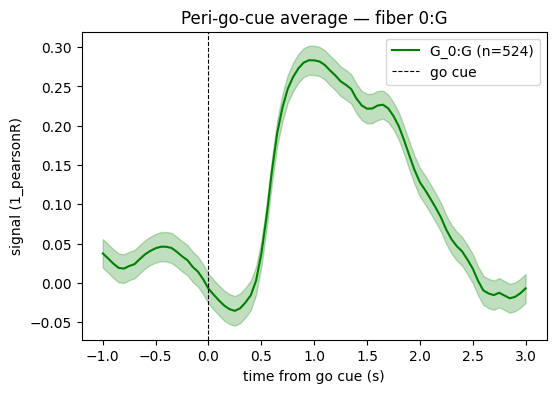

In [21]:
def peri_event(df_fip, event_name, event_times, t_before=1.0, t_after=3.0, fs=20):
    """Align one FIP series to a set of event times using the AIND ETR primitive.

    Parameters
    ----------
    df_fip : pd.DataFrame
        Long-form FIP table (cols include 'event', 'timestamps', 'data').
    event_name : str
        Which series to align (one value of df_fip['event'], e.g. 'G_1_dff-poly').
    event_times : 1D array
        Event times in the SAME clock as df_fip['timestamps'] (first-go-cue-zeroed),
        i.e. taken from a df_trials '*_in_session' column.
    t_before, t_after : float
        Seconds before / after each event to include.
    fs : float
        Output sampling rate (Hz) for the common interpolation grid. FIP is ~20 Hz.

    Returns
    -------
    pd.DataFrame
        Tidy ETR with columns ['time', 'event_number', 'event_time', 'data'];
        'time' is offset from the event (s), 'data' is the interpolated signal.
    """
    one_series = df_fip[df_fip["event"] == event_name]
    return alignment.event_triggered_response(
        data=one_series,
        t="timestamps",
        y="data",
        event_times=np.asarray(event_times, dtype=float),
        t_before=t_before,
        t_after=t_after,
        output_sampling_rate=fs,
        output_format="tidy",
        censor=True,  # blank samples that spill past the next go cue
    )


# Event times must be on the df_fip clock -> use the *_in_session column.
ALIGN_COL = "goCue_start_time_in_session"
assert df_trials is not None and ALIGN_COL in df_trials.columns, (
    f"Need '{ALIGN_COL}' on df_trials (first-go-cue-zeroed clock). "
    f"Available: {None if df_trials is None else list(df_trials.columns)}"
)

# Green trace for the chosen fiber/variant (reuses FIBER/VARIANT/meta from sections 4-5).
match = meta[(meta["channel"] == "G") & (meta["fiber"] == FIBER) & (meta["variant"] == VARIANT)]
assert not match.empty, "No green trace for chosen fiber/variant; adjust FIBER/VARIANT."
event_name = match["event"].iloc[0]

go_cues = df_trials[ALIGN_COL].dropna().to_numpy()
etr = peri_event(df_fip, event_name, go_cues, t_before=1.0, t_after=3.0, fs=20)

# Mean +/- SEM across trials at each grid offset.
agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
n_trials = etr["event_number"].nunique()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(agg["time"], agg["mean"], color="green", label=f"G_{FIBER}{label_suffix} (n={n_trials})")
ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                color="green", alpha=0.25)
ax.axvline(0, color="k", lw=0.8, ls="--", label="go cue")
ax.set_xlabel("time from go cue (s)")
ax.set_ylabel(f"signal ({VARIANT})")
ax.set_title(f"Peri-go-cue average — fiber {FIBER}{label_suffix}")
ax.legend()
plt.show()

## 8. Align motion energy to the go-cue clock

`motion energy` is computed per video frame by **`aind-motion-energy`** (one value per frame,
1-to-1 with the camera CSV rows). To compare it with photometry we put it on the **same
first-go-cue-zeroed session clock** as `df_fip['timestamps']`, using the `video_alignment`
package.

**Data — attach both assets alongside the parquet asset:**
- behavior video CSV: `behavior_<subj>_<date>_*/behavior-videos/bottom_camera.csv`
  (headerless: `Behav_Time, Frame, Camera_Time, Gain, Exposure`)
- motion energy: `behavior_<subj>_<date>_*motionenergy*/.../bottom_camera_motion_energy_clean.npy`
  (we use the keyframe-cleaned trace)

**Clock math (why it lines up):** each frame has an absolute `Behav_Time`. The package sets
`offset = first_go_cue − first_frame_behavior_time` and
`session_time = video_time − offset`, which reduces to
`session_time = Behav_Time − first_go_cue`. That is exactly the `t0` subtraction
`create_df_fip` applies, so motion energy lands natively on the FIP axis. The first go cue is
`df_trials['go_cue_start_time_raw']` — the **absolute** clock, not `*_in_session`.

In [22]:
# --- 8a. Locate the behavior-video + motion-energy assets for THIS session ---
# Both are matched by subject_date; the behavior folders carry an acquisition-time
# suffix (e.g. behavior_808054_2025-09-02_10-38-37), so we glob.
subject, date = nwb.session_id.split("_")[:2]

beh_dirs = [d for d in sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*"))
            if "motionenergy" not in d]
assert beh_dirs, f"No behavior-video asset for {subject}_{date} under /root/capsule/data"
video_csv = os.path.join(beh_dirs[0], "behavior-videos", "bottom_camera.csv")
assert os.path.exists(video_csv), f"missing {video_csv}"

me_dirs = sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*motionenergy*"))
assert me_dirs, f"No motion-energy asset for {subject}_{date}"
hits = glob.glob(os.path.join(me_dirs[0], "**", "bottom_camera_motion_energy_clean.npy"),
                 recursive=True)
assert hits, f"bottom_camera_motion_energy_clean.npy not found under {me_dirs[0]}"
me_path = hits[0]

print("video_csv:", video_csv)
print("me_path:  ", me_path)

video_csv: /root/capsule/data/behavior_808054_2025-09-02_10-38-37/behavior-videos/bottom_camera.csv
me_path:   /root/capsule/data/behavior_808054_2025-09-02_10-38-37_motionenergy_2026-06-29_11-56-53/bottom_camera_motion_energy_clean.npy


In [23]:
# --- 8b. Put motion energy on the first-go-cue-zeroed session clock (the df_fip axis) ---
# The package is editable-installed under /src but checked out on `main`, which lacks
# video_alignment.py (it's on the `video_alignment` branch). Editable installs track the
# working tree, so switching that checkout to the branch makes the submodule importable.
# NB: this is a per-session fix; the permanent one is to point the Dockerfile install ref at
# @video_alignment (or merge the branch to main).
import sys, subprocess, importlib
from pathlib import Path

try:
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va
except ImportError:
    try:
        import aind_dynamic_foraging_behavior_video_analysis as _pkg
        repo = Path(_pkg.__file__).resolve().parents[2]  # /src/aind-dynamic-foraging-behavior-video-analysis
        print(f"switching {repo} to the video_alignment branch")
        subprocess.check_call(["git", "-C", str(repo), "fetch", "-q", "origin", "video_alignment"])
        subprocess.check_call(["git", "-C", str(repo), "checkout", "video_alignment"])
    except ModuleNotFoundError:
        # not installed at all -> install the branch fresh
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
            "git+https://github.com/AllenNeuralDynamics/"
            "aind-dynamic-foraging-behavior-video-analysis.git@video_alignment"])
    importlib.invalidate_caches()
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va

# Camera CSV is headerless with this column layout (matches va's DEFAULT_COLUMNS).
CAM_COLUMNS = ["Behav_Time", "Frame", "Camera_Time", "Gain", "Exposure"]


def motion_energy_to_session(me_path, video_csv, df_trials,
                             go_cue_col="goCue_start_time_raw"):
    """Per-frame motion energy on the session clock (t=0 at first go cue).

    ME[i] is 1-to-1 with row i of the camera CSV, so
        session_time = Behav_Time(frame) - first_go_cue_raw,
    which is exactly how df_fip['timestamps'] is built. Routed through the
    video_alignment helpers so the offset semantics stay in one place.

    Returns (t_session, me, offset).
    """
    me = np.load(me_path)
    cam = pd.read_csv(video_csv, header=None, names=CAM_COLUMNS)
    if len(me) != len(cam):
        n = min(len(me), len(cam))
        print(f"WARNING: {len(me)} ME frames vs {len(cam)} CSV rows; truncating to {n}")
        me, cam = me[:n], cam.iloc[:n]

    first_go_cue = float(df_trials.sort_values("trial")[go_cue_col].iloc[0])  # absolute behav clock
    offset = va.compute_video_session_offset(video_csv, first_go_cue)
    first_frame = va.get_first_frame_behavior_time(video_csv)
    video_t = va.behavior_time_to_video_time(cam["Behav_Time"].to_numpy(float), first_frame)
    t_session = va.video_time_to_session_time(video_t, offset)
    return t_session, np.asarray(me, float), offset


t_me, me, offset = motion_energy_to_session(me_path, video_csv, nwb.df_trials)

offset = 607.039 s  (first go cue this far into the video; expect small, positive)
ME session-time range:    -607.0 ..   4884.5 s
FIP timestamps range:       -1.0 ..   4493.5 s


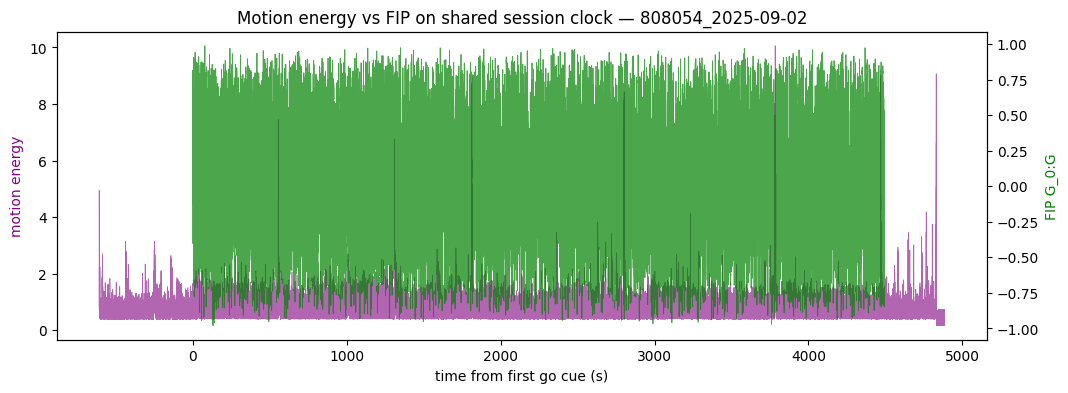

In [24]:
# --- 8c. Verify the alignment BEFORE trusting it ---
# offset should be small and positive (first go cue a little way into the video),
# and the ME session-time range should overlap the FIP timestamps range.
print(f"offset = {offset:.3f} s  (first go cue this far into the video; expect small, positive)")
print(f"ME session-time range:  {t_me.min():8.1f} .. {t_me.max():8.1f} s")
print(f"FIP timestamps range:   {df_fip['timestamps'].min():8.1f} .. {df_fip['timestamps'].max():8.1f} s")

gname = meta[(meta.channel == "G") & (meta.fiber == FIBER) & (meta.variant == VARIANT)]["event"].iloc[0]
gsub = df_fip[df_fip.event == gname].sort_values("timestamps")

fig, ax = plt.subplots()
ax.plot(t_me, me, lw=0.5, color="purple", alpha=0.6, label="motion energy")
ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel("motion energy", color="purple")
ax2 = ax.twinx()
ax2.plot(gsub.timestamps, gsub.data, lw=0.6, color="green", alpha=0.7)
ax2.set_ylabel(f"FIP G_{FIBER}", color="green")
ax.set_title(f"Motion energy vs FIP on shared session clock — {nwb.session_id}")
plt.show()

2119 movement onsets (thr=0.996)


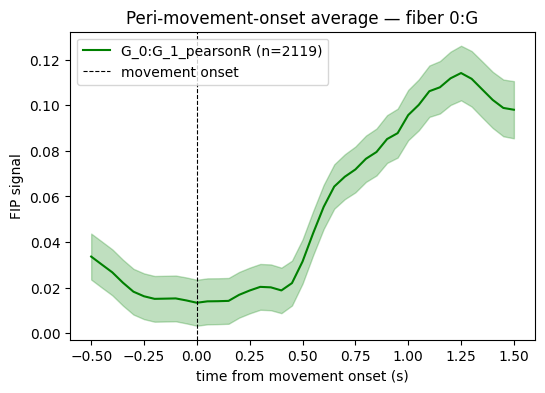

In [25]:
# --- 8d. Movement onsets from motion energy -> reuse peri_event() from section 7 ---
from scipy.ndimage import uniform_filter1d

me_s = uniform_filter1d(np.nan_to_num(me, nan=float(np.nanmedian(me))), size=5)
# robust threshold: median + 3 * (MAD-based sigma)
med = np.nanmedian(me_s)
mad_sigma = 1.4826 * np.nanmedian(np.abs(me_s - med))
thr = med + 3 * mad_sigma

above = me_s > thr
onset_idx = np.where((~above[:-1]) & above[1:])[0] + 1
onset_times = t_me[onset_idx]
if len(onset_times):  # 0.5 s refractory so one bout counts once
    onset_times = onset_times[np.insert(np.diff(onset_times) > 0.5, 0, True)]
print(f"{len(onset_times)} movement onsets (thr={thr:.3g})")

# align FIP to movement onsets — same wrapper, just different event times
etr_mv = peri_event(df_fip, gname, onset_times, t_before=0.5, t_after=1.5, fs=20)
agg_mv = etr_mv.groupby("time")["data"].agg(["mean", "sem"]).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(agg_mv["time"], agg_mv["mean"], color="green",
        label=f"{gname} (n={etr_mv['event_number'].nunique()})")
ax.fill_between(agg_mv["time"], agg_mv["mean"] - agg_mv["sem"], agg_mv["mean"] + agg_mv["sem"],
                color="green", alpha=0.25)
ax.axvline(0, color="k", lw=0.8, ls="--", label="movement onset")
ax.set_xlabel("time from movement onset (s)")
ax.set_ylabel("FIP signal")
ax.set_title(f"Peri-movement-onset average — fiber {FIBER}{label_suffix}")
ax.legend()
plt.show()

## 9. Three example signals

Now that curation has annotated `intended_measurement`, pick one representative series per
signal *type* and carry them through the rest of the notebook:

- **NAc DA** — dopamine (dLight, green channel)
- **PL** — GCaMP (green channel)
- **NAc ACh** — acetylcholine (rAch, red channel)

`pick_example` matches on the region label, prefers a `dff` variant, and breaks ties by the
series with the most finite samples. Requires `USE_CURATION=True` (section 3) so that
`df_fip` carries `intended_measurement` (and therefore `meta['region']`).


In [ ]:
# --- Helpers for sections 9-16 (z-scoring, threshold onsets, generic peri-event, xcorr) ---
from scipy.ndimage import uniform_filter1d


def zscore(y):
    """Z-score a 1D array, ignoring NaNs."""
    y = np.asarray(y, float)
    sd = np.nanstd(y)
    return (y - np.nanmean(y)) / sd if sd > 0 else y - np.nanmean(y)


def threshold_onsets(t, y, z_thresh=2.5, refractory=0.5, smooth=5):
    """Upward threshold crossings of a z-scored (optionally smoothed) trace.

    Returns the times (in t's units) where the signal first rises above `z_thresh` SD,
    with a `refractory` (s) dead-time so one bout is counted once.
    """
    y = np.asarray(y, float)
    if smooth and smooth > 1:
        y = uniform_filter1d(np.nan_to_num(y, nan=float(np.nanmedian(y))), size=smooth)
    z = zscore(y)
    above = z > z_thresh
    idx = np.where((~above[:-1]) & above[1:])[0] + 1
    times = np.asarray(t, float)[idx]
    if len(times):  # enforce refractory period
        times = times[np.insert(np.diff(times) > refractory, 0, True)]
    return times


def peri_event_series(t, y, event_times, t_before=0.5, t_after=1.5, fs=20, censor=False):
    """Peri-event align an arbitrary (t, y) timeseries via the AIND ETR primitive.

    Generalises `peri_event` (section 7) to any signal already pulled out as arrays
    (motion energy on `t_me`, or a z-scored FIP trace) rather than a df_fip 'event' row.
    `censor=False` keeps full windows even when events are closely spaced.
    """
    s = (pd.DataFrame({"timestamps": np.asarray(t, float), "data": np.asarray(y, float)})
         .dropna().sort_values("timestamps"))
    return alignment.event_triggered_response(
        data=s, t="timestamps", y="data",
        event_times=np.asarray(event_times, float),
        t_before=t_before, t_after=t_after,
        output_sampling_rate=fs, output_format="tidy", censor=censor)


def norm_xcorr(a, b, fs, maxlag=3.0):
    """Normalised cross-correlation of two equal-length, uniformly-sampled signals.

    out[lag] = mean( a[t+lag] * b[t] ) with a, b z-scored. A peak at POSITIVE lag means
    b LEADS a (b precedes a by `lag` seconds).
    """
    a, b = zscore(a), zscore(b)
    n = len(a)
    K = int(round(maxlag * fs))
    lags = np.arange(-K, K + 1)
    out = np.empty(len(lags), float)
    for i, L in enumerate(lags):
        if L >= 0:
            out[i] = np.nanmean(a[L:] * b[:n - L])
        else:
            out[i] = np.nanmean(a[:n + L] * b[-L:])
    return lags / float(fs), out


In [ ]:
def pick_example(meta, df_fip, region_substr, prefer_variant="dff"):
    """Choose one df_fip 'event' whose region label matches `region_substr`.

    Prefers a dff variant, then the series with the most finite samples.
    """
    if "region" not in meta.columns or meta["region"].dropna().empty:
        raise RuntimeError(
            "No region labels on `meta` -- set USE_CURATION=True (section 3) with the "
            "DA_NE_4channel curation so df_fip carries intended_measurement.")
    cand = meta[meta["region"].fillna("").str.contains(region_substr, case=False)]
    if cand.empty:
        raise ValueError("No FIP series with region matching %r. Have: %s"
                         % (region_substr, sorted(meta["region"].dropna().unique())))
    pref = cand[cand["variant"].str.contains(prefer_variant, case=False)]
    pool = pref if not pref.empty else cand
    best = max(pool["event"], key=lambda ev: int(np.isfinite(get_trace(df_fip, ev)[1]).sum()))
    row = pool[pool["event"] == best].iloc[0]
    return {"event": best, "region": row["region"], "channel": row["channel"],
            "variant": row["variant"]}


# (region substring, plot colour) for each example signal type.
EXAMPLE_SPECS = [
    ("NAc DA (dLight)", "dLight", "#2ca02c"),
    ("PL (GCaMP)",      "Gcamp",  "#1f77b4"),
    ("NAc ACh (rAch)",  "rAch",   "#d62728"),
]

examples = []
for label, substr, color in EXAMPLE_SPECS:
    info = pick_example(meta, df_fip, substr)
    info["label"], info["color"] = label, color
    examples.append(info)

pd.DataFrame(examples)[["label", "event", "channel", "region", "variant", "color"]]


## 10. Full-session traces of the three examples


In [ ]:
fig, axes = plt.subplots(len(examples), 1, sharex=True, figsize=(12, 2.2 * len(examples)))
for ax, ex in zip(np.atleast_1d(axes), examples):
    t, y = get_trace(df_fip, ex["event"])
    ax.plot(t, y, color=ex["color"], lw=0.5, alpha=0.85)
    ax.set_ylabel(ex["variant"])
    ax.set_title("%s  -  %s" % (ex["label"], ex["event"]), loc="left", fontsize=10)
np.atleast_1d(axes)[-1].set_xlabel("time from first go cue (s)")
fig.suptitle("Full-session traces - %s" % nwb.session_id)
fig.tight_layout()
plt.show()


## 11. 60-second window with go cues


In [ ]:
WINDOW = (0, 60)  # seconds from first go cue
cues = None
if cue_col is not None:  # cue_col detected in section 6
    cues = df_trials[cue_col]
    cues = cues[(cues >= WINDOW[0]) & (cues <= WINDOW[1])].to_numpy()

fig, axes = plt.subplots(len(examples), 1, sharex=True, figsize=(12, 2.2 * len(examples)))
for ax, ex in zip(np.atleast_1d(axes), examples):
    t, y = get_trace(df_fip, ex["event"])
    m = (t >= WINDOW[0]) & (t <= WINDOW[1])
    ax.plot(t[m], y[m], color=ex["color"], lw=0.9, label=ex["label"])
    if cues is not None:
        for c in cues:
            ax.axvline(c, color="k", lw=0.5, alpha=0.35)
    ax.set_ylabel(ex["variant"])
    ax.legend(loc="upper right", fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("time from first go cue (s)")
fig.suptitle("First %d s with go cues - %s" % (WINDOW[1], nwb.session_id))
fig.tight_layout()
plt.show()


## 12. Peri-go-cue averages — each example signal

Reuses `peri_event` (section 7); native dff units per panel.


In [ ]:
go_cues = df_trials[ALIGN_COL].dropna().to_numpy()  # ALIGN_COL = first-go-cue-zeroed clock

fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 3.5))
for ax, ex in zip(np.atleast_1d(axes), examples):
    etr = peri_event(df_fip, ex["event"], go_cues, t_before=1.0, t_after=3.0, fs=20)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"])
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.25)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title("%s\n(n=%d cues)" % (ex["label"], etr["event_number"].nunique()), fontsize=9)
    ax.set_xlabel("time from go cue (s)")
np.atleast_1d(axes)[0].set_ylabel("signal (dff)")
fig.suptitle("Peri-go-cue averages")
fig.tight_layout()
plt.show()


## 13. Z-score motion energy

Smooth (5-frame) then z-score the motion-energy trace so the threshold is in SD units and comparable across sessions. `me_z` and the onset times feed sections 14-16.


In [ ]:
me_smooth = uniform_filter1d(np.nan_to_num(me, nan=float(np.nanmedian(me))), size=5)
me_z = zscore(me_smooth)

# Movement onsets = upward crossings of z-scored ME (SD-unit version of the 8d MAD threshold).
Z_THRESH = 2.5
me_onset_times = threshold_onsets(t_me, me, z_thresh=Z_THRESH, refractory=0.5, smooth=5)
print("%d motion-energy onsets at z>%.1f" % (len(me_onset_times), Z_THRESH))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_me, me_z, color="purple", lw=0.5, alpha=0.7)
ax.axhline(Z_THRESH, color="k", ls="--", lw=0.8, label="z=%.1f" % Z_THRESH)
ax.plot(me_onset_times, np.full(len(me_onset_times), Z_THRESH), "v", color="k", ms=4,
        label="onsets")
ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title("Z-scored motion energy - %s" % nwb.session_id)
ax.legend(loc="upper right", fontsize=8)
plt.show()


## 14. Align FIP to motion-energy threshold crossings

For each example signal, average its **z-scored** trace around motion-energy onsets (section 13). Does each neuromodulator move with gross body movement?


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    etr = peri_event_series(t, zscore(y), me_onset_times, t_before=0.5, t_after=1.5, fs=20)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"], label=ex["label"])
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.2)
ax.axvline(0, color="k", lw=0.8, ls="--", label="ME onset")
ax.set_xlabel("time from motion-energy onset (s)")
ax.set_ylabel("FIP signal (z)")
ax.set_title("FIP aligned to motion-energy onsets (n=%d)" % len(me_onset_times))
ax.legend(fontsize=8)
plt.show()


## 15. Align motion energy to FIP threshold crossings

The reverse direction: detect each signal's own transients (z-scored upward crossings) and average **motion energy** around them. A pre-transient rise in ME means movement tends to precede that signal.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    fip_onsets = threshold_onsets(t, y, z_thresh=2.0, refractory=1.0, smooth=3)
    etr = peri_event_series(t_me, me_z, fip_onsets, t_before=1.0, t_after=1.0, fs=20)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"],
            label="%s (n=%d)" % (ex["label"], len(fip_onsets)))
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.2)
ax.axvline(0, color="k", lw=0.8, ls="--", label="FIP transient")
ax.set_xlabel("time from FIP transient onset (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title("Motion energy aligned to each signal's transients")
ax.legend(fontsize=8)
plt.show()


## 16. Cross-correlation of motion energy with FIP

Resample motion energy and each FIP trace onto a common 20 Hz grid over their overlapping time range, then cross-correlate. Peak-lag sign shows which leads (positive = motion energy leads FIP).


In [ ]:
FS_XC = 20      # Hz, common resampling grid
MAXLAG = 3.0    # s

fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    finite = np.isfinite(t) & np.isfinite(y)
    t, y = t[finite], y[finite]
    lo = max(t.min(), t_me.min())
    hi = min(t.max(), t_me.max())
    grid = np.arange(lo, hi, 1.0 / FS_XC)
    fip_i = np.interp(grid, t, y)          # FIP on common grid
    me_i = np.interp(grid, t_me, me_z)     # ME (z) on common grid
    lags, c = norm_xcorr(fip_i, me_i, fs=FS_XC, maxlag=MAXLAG)
    peak = lags[int(np.argmax(c))]
    ax.plot(lags, c, color=ex["color"], label="%s (peak %+.2fs)" % (ex["label"], peak))
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("lag (s)   -   positive = motion energy leads FIP")
ax.set_ylabel("normalised cross-correlation")
ax.set_title("Motion energy x FIP cross-correlation")
ax.legend(fontsize=8)
plt.show()


## 17. Next: tongue kinematics

Motion energy is a whole-frame movement proxy. Tongue-kinematics bouts (lick detection,
`compute_outbound_metrics`) will yield movement onsets on the same go-cue-aligned clock, so
they drop straight into the identical `peri_event` / `peri_event_series` calls above. Single-
trial FIP features can then be correlated against per-bout kinematic features.
